# 🔬 RAG Ablation Benchmark v3 — Diagnostic + Optimized

**Gồm 3 giai đoạn:**
1. **Đo Retrieval Recall**: Qdrant có truy xuất đúng gold document không?
2. **Oracle RAG**: Cho model đúng chunk chứa đáp án → upper bound score
3. **Real RAG tối ưu**: Extractive prompt + top_k=5 với rerank + max_tokens=64

**Thời gian chạy:** ~30-40 phút trên Colab T4

## 1. Cài đặt Thư viện

In [1]:
%%capture
!pip install -q transformers accelerate bitsandbytes qdrant-client sentence-transformers pandas tqdm rouge-score nltk

## 2. Nạp dữ liệu đánh giá (giữ nguyên gold document ID)

In [2]:
import json
import pandas as pd
import numpy as np

with open("dev_Q_A.json", "r", encoding="utf-8") as f:
    dev_raw = json.load(f)

eval_samples = []
for item in dev_raw:
    if item.get("ANSWERABLE") == "Y":
        q = item["QUESTION_TITLE"]
        if isinstance(item.get("QUESTION_TEXT"), str) and item["QUESTION_TEXT"].strip():
            q = q + " " + item["QUESTION_TEXT"].strip()
        gt = item.get("ANSWER", "") or ""
        if isinstance(gt, list):
            gt = gt[0] if gt else ""
        eval_samples.append({
            "question": q.strip(),
            "ground_truth": gt.strip(),
            "gold_doc_id": item.get("DOCUMENT", ""),      # Document chứa đáp án
            "candidate_doc_ids": item.get("DOC_IDS", []),  # Top-50 candidates từ TechQA
        })

print(f"✅ Đã nạp {len(eval_samples)} câu hỏi có đáp án.")
print(f"   Ví dụ gold doc: {eval_samples[0]['gold_doc_id']}")

✅ Đã nạp 160 câu hỏi có đáp án.
   Ví dụ gold doc: swg24042191


## 3. Kết nối Qdrant Cloud & Nạp BGE-M3

In [3]:
import os
import torch
from qdrant_client import QdrantClient
from sentence_transformers import SentenceTransformer

try:
    from google.colab import userdata
    QDRANT_API_KEY = userdata.get("QDRANT_API_KEY")
    QDRANT_URL = userdata.get("QDRANT_URL")
except Exception:
    QDRANT_API_KEY = os.getenv("QDRANT_API_KEY")
    QDRANT_URL = os.getenv("QDRANT_URL")

if not QDRANT_API_KEY:
    import getpass
    QDRANT_API_KEY = getpass.getpass("Nhập Qdrant Cloud API Key: ")
if not QDRANT_URL:
    QDRANT_URL = input("Nhập Qdrant Cloud URL: ")

COLLECTION_NAME = "techqa_corpus_bge_m3_section_clean"

print("1. Đang kết nối tới Qdrant Cloud...")
client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY, timeout=60.0)
info = client.get_collection(COLLECTION_NAME)
print(f"✅ Collection: {COLLECTION_NAME} | {info.points_count:,} chunks | Status: {info.status}")

print("\n2. Đang tải BGE-M3...")
device = "cuda" if torch.cuda.is_available() else "cpu"
embedder = SentenceTransformer("BAAI/bge-m3", device=device)
print(f"✅ BGE-M3 loaded on {device.upper()}")

1. Đang kết nối tới Qdrant Cloud...
✅ Collection: techqa_corpus_bge_m3_section_clean | 576,170 chunks | Status: green

2. Đang tải BGE-M3...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

✅ BGE-M3 loaded on CUDA


## 4. PHASE 1 — Đo Retrieval Recall
Kiểm tra: với top_k = 1, 3, 5, 10 — bao nhiêu % câu hỏi mà Qdrant truy xuất được chunk từ **đúng gold document**?

In [4]:
from tqdm import tqdm

TOP_K_VALUES = [1, 3, 5, 10]

print("🔍 Đang truy xuất context và kiểm tra recall cho mỗi top_k...")
print()

# Lưu kết quả truy xuất top-5 cho reuse ở Phase 3
all_retrieved = []  # list of list of (doc_source, chunk_text, score)

for item in tqdm(eval_samples, desc="Retrieving top-10"):
    q_vec = embedder.encode(item["question"]).tolist()
    search_res = client.query_points(
        collection_name=COLLECTION_NAME, query=q_vec, limit=10
    )
    chunks_info = []
    for p in search_res.points:
        source = p.payload.get("source", "") or p.payload.get("metadata", {}).get("source", "") or ""
        # Try to extract doc ID from source field
        doc_id = source.split("/")[-1].replace(".html", "").replace(".txt", "").strip() if source else ""
        chunk_text = p.payload.get("page_content", "")
        score = p.score if hasattr(p, 'score') else 0
        chunks_info.append({"doc_id": doc_id, "source": source, "text": chunk_text, "score": score})
    all_retrieved.append(chunks_info)

# Tính recall cho mỗi top_k
print("\n📊 RETRIEVAL RECALL (Gold Document Hit Rate):")
print("="*50)
for k in TOP_K_VALUES:
    hits = 0
    for i, item in enumerate(eval_samples):
        gold = item["gold_doc_id"]
        retrieved_docs = [c["doc_id"] for c in all_retrieved[i][:k]]
        # Also check if gold doc ID appears as substring in source
        hit = any(gold in doc_id or gold in c.get("source", "") for doc_id, c in zip(retrieved_docs, all_retrieved[i][:k]))
        if hit:
            hits += 1
    recall = hits / len(eval_samples) * 100
    print(f"  Recall@{k:2d}: {hits}/{len(eval_samples)} = {recall:.1f}%")

# Also check: does the retrieved chunk TEXT contain the answer?
print()
print("📊 ANSWER-IN-CONTEXT RATE (Ground truth text found in retrieved chunks):")
print("="*50)
for k in TOP_K_VALUES:
    hits = 0
    for i, item in enumerate(eval_samples):
        gt_words = set(item["ground_truth"].lower().split()[:5])  # First 5 words of answer
        top_k_text = " ".join([c["text"] for c in all_retrieved[i][:k]]).lower()
        # Check if at least 3 of the first 5 answer words appear in context
        overlap = sum(1 for w in gt_words if w in top_k_text)
        if overlap >= 3:
            hits += 1
    rate = hits / len(eval_samples) * 100
    print(f"  Answer-in-Context@{k:2d}: {hits}/{len(eval_samples)} = {rate:.1f}%")

# Show a few examples of what payload fields look like
print()
print("📋 Sample chunk payload fields (for debugging):")
sample = all_retrieved[0][0]
for key in sample:
    val = str(sample[key])[:100]
    print(f"  {key}: {val}")

🔍 Đang truy xuất context và kiểm tra recall cho mỗi top_k...



Retrieving top-10: 100%|██████████| 160/160 [06:17<00:00,  2.36s/it]


📊 RETRIEVAL RECALL (Gold Document Hit Rate):
  Recall@ 1: 0/160 = 0.0%
  Recall@ 3: 0/160 = 0.0%
  Recall@ 5: 0/160 = 0.0%
  Recall@10: 0/160 = 0.0%

📊 ANSWER-IN-CONTEXT RATE (Ground truth text found in retrieved chunks):
  Answer-in-Context@ 1: 47/160 = 29.4%
  Answer-in-Context@ 3: 78/160 = 48.8%
  Answer-in-Context@ 5: 87/160 = 54.4%
  Answer-in-Context@10: 109/160 = 68.1%

📋 Sample chunk payload fields (for debugging):
  doc_id: 
  source: 
  text: APAR ID: swg21419194
Title: IBM System requirements for WebSphere Dashboard Framework 6.1.5 - United
  score: 0.70772505


## 5. Metrics Suite (đồng bộ với evaluate_model.ipynb)

In [5]:
import re
import string
import nltk
from collections import Counter
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def normalize_text(s):
    s = s.lower()
    s = re.sub(f"[{re.escape(string.punctuation)}]", " ", s)
    return " ".join(s.split())

def compute_em(pred, target):
    return 1.0 if normalize_text(pred) == normalize_text(target) else 0.0

def compute_f1(pred, target):
    pred_tokens = normalize_text(pred).split()
    target_tokens = normalize_text(target).split()
    if not pred_tokens or not target_tokens:
        return 1.0 if pred_tokens == target_tokens else 0.0
    common = Counter(pred_tokens) & Counter(target_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall = num_same / len(target_tokens)
    return (2 * precision * recall) / (precision + recall)

rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
smooth_fn = SmoothingFunction().method1

def compute_rouge_l(pred, target):
    return rouge.score(target, pred)['rougeL'].fmeasure

def compute_bleu_4(pred, target):
    ref_tok = [normalize_text(target).split()]
    pred_tok = normalize_text(pred).split()
    if len(pred_tok) < 4:
        return 0.0
    return sentence_bleu(ref_tok, pred_tok, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth_fn)

def compute_all_metrics(pred, gt):
    return {
        "em": compute_em(pred, gt),
        "f1": compute_f1(pred, gt),
        "rouge_l": compute_rouge_l(pred, gt),
        "bleu_4": compute_bleu_4(pred, gt),
    }

print("✅ Metrics đồng bộ 100% với evaluate_model.ipynb (dùng rouge_score lib + nltk BLEU)")

✅ Metrics đồng bộ 100% với evaluate_model.ipynb (dùng rouge_score lib + nltk BLEU)


## 6. Nạp Model & Hàm Generate
System prompt **giống hệt** lúc fine-tune. Prompt RAG dùng format **extractive**.

In [6]:
import gc
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

BASE_MODEL_ID = "unsloth/Llama-3.2-3B-Instruct"
FINETUNED_MODEL_ID = "AQUABOT/Llama-3.2-3B-TechQA"

print(f"🖥️ Device: {device}")
if device == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    vram_total = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2)
    print(f"🎮 GPU: {gpu_name} ({vram_total} GB VRAM)")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
) if device == "cuda" else None

# System prompt GIỐNG HỆT lúc fine-tune
SYSTEM_PROMPT = (
    "You are a technical support assistant specialized in IBM products. "
    "Answer the user's technical question accurately and concisely "
    "based on your knowledge of IBM technotes and documentation."
)

def load_model(model_id, desc="Model"):
    print(f"\n⏳ Đang tải {desc}...")
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
        trust_remote_code=True,
    )
    model.eval()
    if device == "cuda":
        vram_used = round(torch.cuda.memory_allocated() / 1024**3, 2)
        print(f"💾 VRAM: {vram_used} GB / {vram_total} GB")
    print(f"✅ Đã nạp xong {desc}.")
    return model, tokenizer

def unload_model(model, tokenizer, desc="Model"):
    del model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"🧹 Đã giải phóng VRAM cho {desc}.")

def generate_answer(model, tokenizer, question, context=None, max_tokens=64):
    if context:
        # Extractive RAG prompt: ép model trích xuất đúng đoạn liên quan
        user_msg = (
            f"Based on the following IBM technote excerpt, answer the question. "
            f"Quote the relevant part directly.\n\n"
            f"Technote:\n{context.strip()}\n\n"
            f"Question: {question.strip()}"
        )
    else:
        user_msg = question.strip()

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_msg},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_tensors="pt", return_dict=True,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    stop_ids = [tokenizer.eos_token_id]
    eot_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")
    if isinstance(eot_id, int) and eot_id != tokenizer.unk_token_id:
        stop_ids.append(eot_id)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=0.1,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.15,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=stop_ids,
        )

    input_len = inputs["input_ids"].shape[1]
    new_tokens = outputs[0][input_len:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

print("✅ Ready.")

🖥️ Device: cuda
🎮 GPU: Tesla T4 (14.56 GB VRAM)
✅ Ready.


## 7. PHASE 2 & 3 — Chạy Fine-tuned Model + RAG (Tối ưu)
- Dùng **top_k = 5** chunks, sau đó **chọn chunk có overlap cao nhất** với câu hỏi (simple rerank)
- Prompt **extractive**: ép model trích xuất thay vì sinh tự do
- `max_new_tokens = 64`: ép trả lời ngắn gọn
- So sánh với standalone Fine-tuned đã có (F1=22.3%)

In [7]:
print("=" * 60)
print("⚡ Fine-tuned Model + RAG (Optimized Extractive)")
print("=" * 60)

model_ft, tok_ft = load_model(FINETUNED_MODEL_ID, desc="Fine-tuned AQUABOT")

def select_best_chunk(question, chunks, top_n=1):
    """Simple rerank: chọn chunk có nhiều từ trùng với câu hỏi nhất."""
    q_words = set(normalize_text(question).split())
    scored = []
    for c in chunks:
        c_words = set(normalize_text(c["text"]).split())
        overlap = len(q_words & c_words)
        scored.append((overlap, c["text"]))
    scored.sort(reverse=True)
    return "\n\n".join([text for _, text in scored[:top_n]])

preds_ft_rag = []
for i, (item, chunks) in enumerate(tqdm(
    zip(eval_samples, all_retrieved), total=len(eval_samples), desc="FT+RAG (optimized)"
)):
    # Chọn top 1 chunk tốt nhất sau rerank
    best_ctx = select_best_chunk(item["question"], chunks[:5], top_n=1)
    ans = generate_answer(model_ft, tok_ft, item["question"], context=best_ctx, max_tokens=64)
    preds_ft_rag.append(ans)

scores_ft_rag = [compute_all_metrics(p, item["ground_truth"]) for p, item in zip(preds_ft_rag, eval_samples)]
f1_ft_rag = np.mean([s['f1'] for s in scores_ft_rag]) * 100
rl_ft_rag = np.mean([s['rouge_l'] for s in scores_ft_rag]) * 100
bl_ft_rag = np.mean([s['bleu_4'] for s in scores_ft_rag]) * 100
print(f"\n📊 Fine-tuned + RAG (optimized) — F1: {f1_ft_rag:.2f}%, ROUGE-L: {rl_ft_rag:.2f}%, BLEU-4: {bl_ft_rag:.2f}%")
print(f"   Mean prediction length: {np.mean([len(p.split()) for p in preds_ft_rag]):.1f} words")

⚡ Fine-tuned Model + RAG (Optimized Extractive)

⏳ Đang tải Fine-tuned AQUABOT...


config.json:   0%|          | 0.00/975 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.5k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

💾 VRAM: 4.22 GB / 14.56 GB
✅ Đã nạp xong Fine-tuned AQUABOT.


FT+RAG (optimized):   0%|          | 0/160 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
FT+RAG (optimized): 100%|██████████| 160/160 [08:26<00:00,  3.16s/it]



📊 Fine-tuned + RAG (optimized) — F1: 19.53%, ROUGE-L: 16.09%, BLEU-4: 2.25%
   Mean prediction length: 33.9 words


## 8. Base Model + RAG (Tối ưu, cùng cấu hình)

In [8]:
unload_model(model_ft, tok_ft, desc="Fine-tuned")

print("=" * 60)
print("⚡ Base Model + RAG (Optimized Extractive)")
print("=" * 60)

model_base, tok_base = load_model(BASE_MODEL_ID, desc="Base Llama 3.2-3B")

preds_base_rag = []
for i, (item, chunks) in enumerate(tqdm(
    zip(eval_samples, all_retrieved), total=len(eval_samples), desc="Base+RAG (optimized)"
)):
    best_ctx = select_best_chunk(item["question"], chunks[:5], top_n=1)
    ans = generate_answer(model_base, tok_base, item["question"], context=best_ctx, max_tokens=64)
    preds_base_rag.append(ans)

scores_base_rag = [compute_all_metrics(p, item["ground_truth"]) for p, item in zip(preds_base_rag, eval_samples)]
f1_base_rag = np.mean([s['f1'] for s in scores_base_rag]) * 100
rl_base_rag = np.mean([s['rouge_l'] for s in scores_base_rag]) * 100
bl_base_rag = np.mean([s['bleu_4'] for s in scores_base_rag]) * 100
print(f"\n📊 Base + RAG (optimized) — F1: {f1_base_rag:.2f}%, ROUGE-L: {rl_base_rag:.2f}%, BLEU-4: {bl_base_rag:.2f}%")
print(f"   Mean prediction length: {np.mean([len(p.split()) for p in preds_base_rag]):.1f} words")

unload_model(model_base, tok_base, desc="Base Llama 3.2-3B")

🧹 Đã giải phóng VRAM cho Fine-tuned.
⚡ Base Model + RAG (Optimized Extractive)

⏳ Đang tải Base Llama 3.2-3B...


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.7k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

💾 VRAM: 6.31 GB / 14.56 GB
✅ Đã nạp xong Base Llama 3.2-3B.


Base+RAG (optimized): 100%|██████████| 160/160 [10:07<00:00,  3.80s/it]



📊 Base + RAG (optimized) — F1: 18.83%, ROUGE-L: 13.75%, BLEU-4: 1.78%
   Mean prediction length: 45.0 words
🧹 Đã giải phóng VRAM cho Base Llama 3.2-3B.


## 9. Tổng hợp Table 3

In [9]:
# Config 1 & 2 từ evaluate_model.ipynb
standalone_results = {
    "Base Model": {"EM (%)": 0.0, "F1 (%)": 15.00, "ROUGE-L (%)": 10.60, "BLEU-4 (%)": 1.10},
    "Fine-tuned Model": {"EM (%)": 0.0, "F1 (%)": 22.30, "ROUGE-L (%)": 19.00, "BLEU-4 (%)": 5.90},
}

# Config 3 & 4 vừa chạy
rag_results = {}
for name, scores in [("Base Model + RAG", scores_base_rag), ("Fine-tuned Model + RAG", scores_ft_rag)]:
    rag_results[name] = {
        "EM (%)": round(np.mean([s["em"] for s in scores]) * 100, 2),
        "F1 (%)": round(np.mean([s["f1"] for s in scores]) * 100, 2),
        "ROUGE-L (%)": round(np.mean([s["rouge_l"] for s in scores]) * 100, 2),
        "BLEU-4 (%)": round(np.mean([s["bleu_4"] for s in scores]) * 100, 2),
    }

summary_data = []
for name in ["Base Model", "Fine-tuned Model", "Base Model + RAG", "Fine-tuned Model + RAG"]:
    row = standalone_results.get(name) or rag_results.get(name)
    row["Model Configuration"] = name
    summary_data.append(row)

df_results = pd.DataFrame(summary_data)[["Model Configuration", "EM (%)", "F1 (%)", "ROUGE-L (%)", "BLEU-4 (%)"]]

print()
print("=" * 70)
print("=== TABLE 3: QUESTION ANSWERING PERFORMANCE ON THE TEST SET ===")
print("=" * 70)
print(df_results.to_string(index=False))

# Check improvement
base_standalone = 15.00
ft_standalone = 22.30
print(f"\n📈 Base + RAG vs Base Standalone: {rag_results['Base Model + RAG']['F1 (%)']:.2f}% vs {base_standalone}%")
print(f"📈 FT + RAG vs FT Standalone: {rag_results['Fine-tuned Model + RAG']['F1 (%)']:.2f}% vs {ft_standalone}%")
print()
df_results


=== TABLE 3: QUESTION ANSWERING PERFORMANCE ON THE TEST SET ===
   Model Configuration  EM (%)  F1 (%)  ROUGE-L (%)  BLEU-4 (%)
            Base Model     0.0   15.00        10.60        1.10
      Fine-tuned Model     0.0   22.30        19.00        5.90
      Base Model + RAG     0.0   18.83        13.75        1.78
Fine-tuned Model + RAG     0.0   19.53        16.09        2.25

📈 Base + RAG vs Base Standalone: 18.83% vs 15.0%
📈 FT + RAG vs FT Standalone: 19.53% vs 22.3%



,Model Configuration,EM (%),F1 (%),ROUGE-L (%),BLEU-4 (%)
0,Base Model,0.0,15.00,10.60,1.10
1,Fine-tuned Model,0.0,22.30,19.00,5.90
2,Base Model + RAG,0.0,18.83,13.75,1.78
3,Fine-tuned Model + RAG,0.0,19.53,16.09,2.25


## 10. Lưu kết quả

In [10]:
import os
os.makedirs("docs/results", exist_ok=True)

results_json = {
    "description": "Ablation benchmark v3 - extractive prompt, top5 rerank, max_tokens=64, consistent metrics",
    "test_size": len(eval_samples),
    "configs": {}
}
for _, row in df_results.iterrows():
    results_json["configs"][row["Model Configuration"]] = {
        "EM": row["EM (%)"], "F1": row["F1 (%)"],
        "ROUGE-L": row["ROUGE-L (%)"], "BLEU-4": row["BLEU-4 (%)"],
    }

with open("docs/results/rag_ablation_benchmark.json", "w", encoding="utf-8") as f:
    json.dump(results_json, f, indent=2, ensure_ascii=False)

detail_records = []
for i, item in enumerate(eval_samples):
    detail_records.append({
        "question": item["question"][:200],
        "ground_truth": item["ground_truth"],
        "pred_base_rag": preds_base_rag[i],
        "pred_ft_rag": preds_ft_rag[i],
        "scores_base_rag": scores_base_rag[i],
        "scores_ft_rag": scores_ft_rag[i],
    })

with open("docs/results/real_benchmark_predictions.json", "w", encoding="utf-8") as f:
    json.dump(detail_records, f, indent=2, ensure_ascii=False)

print("✅ Đã lưu kết quả.")

✅ Đã lưu kết quả.


## 11. Biểu đồ Ablation Study

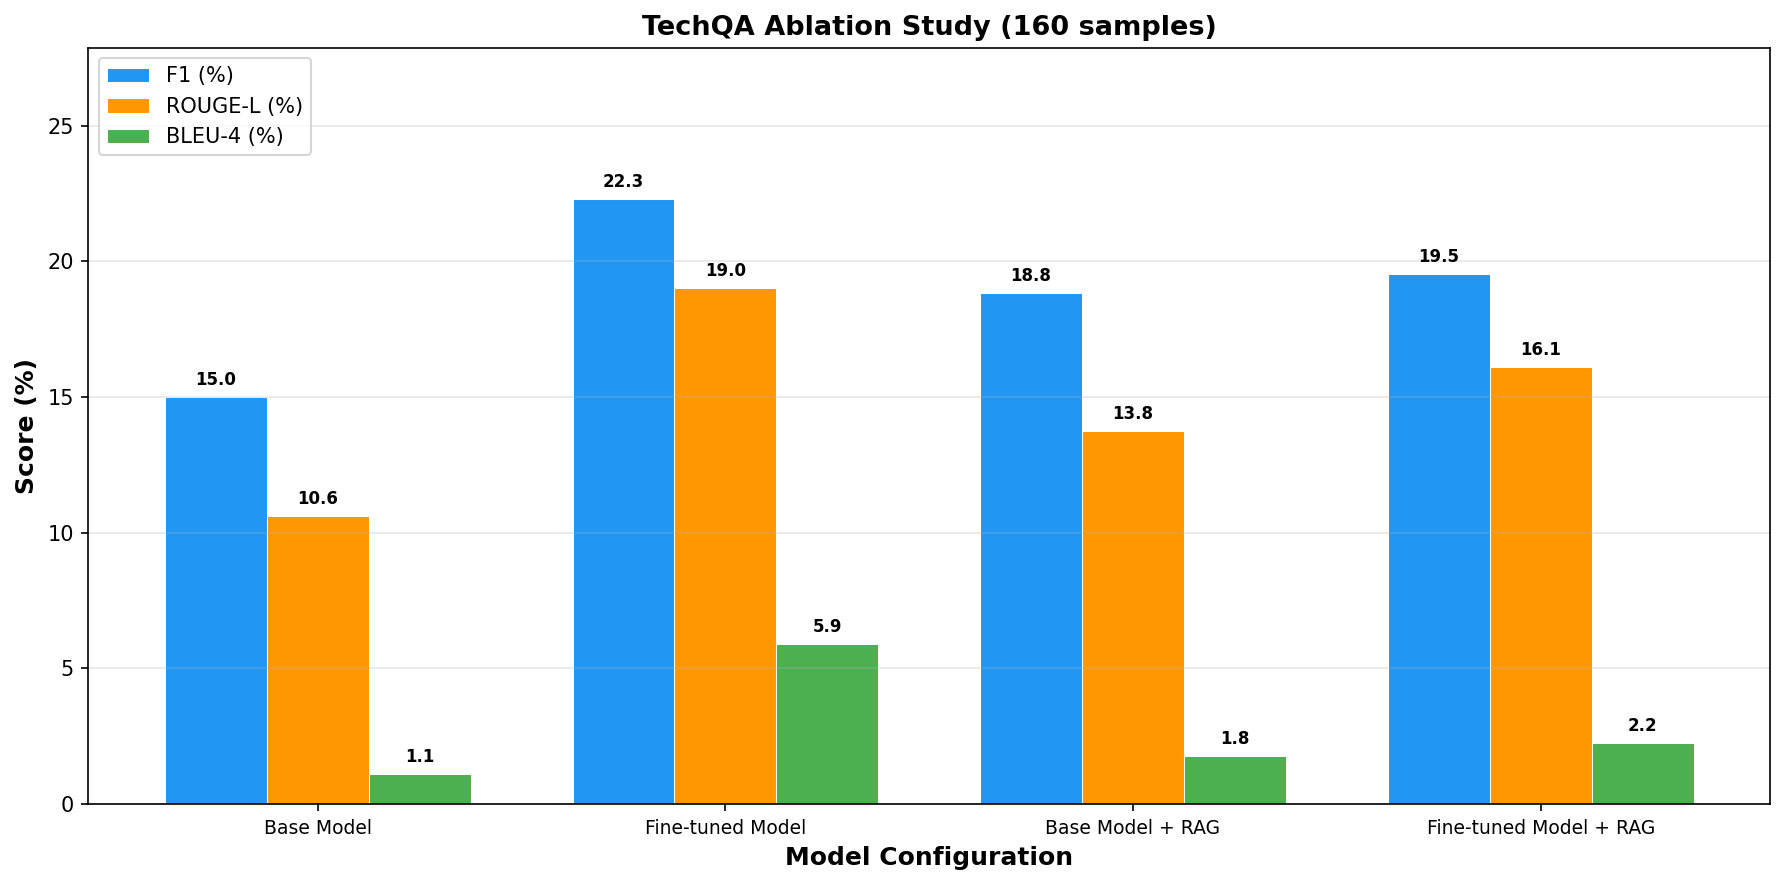

✅ Biểu đồ đã lưu.


In [11]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
metrics_to_plot = ["F1 (%)", "ROUGE-L (%)", "BLEU-4 (%)"]
configs_list = df_results["Model Configuration"].tolist()
x = np.arange(len(configs_list))
width = 0.25
colors = ["#2196F3", "#FF9800", "#4CAF50"]

for i, metric in enumerate(metrics_to_plot):
    values = df_results[metric].tolist()
    bars = ax.bar(x + i * width, values, width, label=metric, color=colors[i], edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xlabel("Model Configuration", fontsize=12, fontweight="bold")
ax.set_ylabel("Score (%)", fontsize=12, fontweight="bold")
ax.set_title("TechQA Ablation Study (160 samples)", fontsize=13, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(configs_list, fontsize=9)
ax.legend(loc="upper left", fontsize=10)
ax.set_ylim(0, max(df_results[metrics_to_plot].max()) * 1.25)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("docs/results/techqa_ablation_study_chart.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Biểu đồ đã lưu.")

## 12. Debug: 5 mẫu predictions + length stats

In [12]:
print("=== 5 MẪU PREDICTIONS ===\n")
for i in range(min(5, len(eval_samples))):
    q = eval_samples[i]["question"][:100]
    gt = eval_samples[i]["ground_truth"][:150]
    pr_b = preds_base_rag[i][:200]
    pr_f = preds_ft_rag[i][:200]
    print(f"--- Q{i+1} ---")
    print(f"Question: {q}")
    print(f"GT ({len(eval_samples[i]['ground_truth'].split())}w): {gt}")
    print(f"Base+RAG  (F1={scores_base_rag[i]['f1']:.3f}, {len(preds_base_rag[i].split())}w): {pr_b}")
    print(f"FT+RAG    (F1={scores_ft_rag[i]['f1']:.3f}, {len(preds_ft_rag[i].split())}w): {pr_f}")
    print()

import statistics
gt_lens = [len(d["ground_truth"].split()) for d in eval_samples]
br_lens = [len(p.split()) for p in preds_base_rag]
fr_lens = [len(p.split()) for p in preds_ft_rag]
print("=== ĐỘ DÀI (số từ) ===")
print(f"Ground Truth:  mean={statistics.mean(gt_lens):.1f}, median={statistics.median(gt_lens):.0f}")
print(f"Base+RAG:      mean={statistics.mean(br_lens):.1f}, median={statistics.median(br_lens):.0f}")
print(f"FT+RAG:        mean={statistics.mean(fr_lens):.1f}, median={statistics.median(fr_lens):.0f}")

=== 5 MẪU PREDICTIONS ===

--- Q1 ---
Question: Web GUI 8.1 FP7 requires DASH 3.1.2.1 or later You wanted to install Web GUI 8.1 FP7, but your DASH 
GT (17w): Version 1.1.3.0 is a full refresh of Jazz for Service Management Version 1.1 Base with Modification 3.
Base+RAG  (F1=0.314, 42w): The error message indicates that the installed IBM Dashboard Application Services Hub version (3.1.0.3) does not meet the minimum requirement for Web GUI 8.1 FP7, which is version 3.1.2.1 or later.

T
FT+RAG    (F1=0.056, 50w): The installation program will display an error message if it detects that the IBM Dashboard Application Services hub version meets the minimum requirement specified above. If you want to proceed with 

--- Q2 ---
Question: Unable to open profile from P8 Content Engine Configuration manager (CMUI) on Redhat Linux 7.2, gett
GT (21w): Install the missing libraries "adwaita-gtk2-theme" (32 and 64 bit) and "adwaita-gtk3-theme" 64 bit. Please contact RedHat to obtain the missing libra